In [3]:
import pandas as pd
import numpy as np
import math

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = pd.read_csv("Salary_Data.csv")
data.head(10)

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891
5,2.9,56642
6,3.0,60150
7,3.2,54445
8,3.2,64445
9,3.7,57189


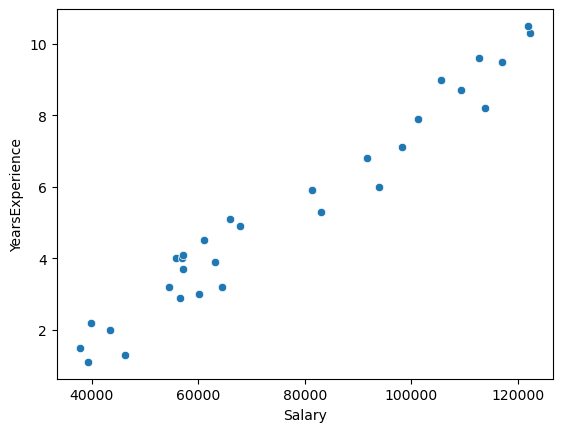

In [9]:
sns.scatterplot(data=data, x="Salary", y="YearsExperience")
plt.show()

In this case, Salary will be our dependet variable, Years of Experience will be our independet variable.

I will use OLS for regression analysis, but not use ready-to-use object that python have, I will calculate by mathematical formulas.

$$
Y = \beta_0 + \beta_1 X + \epsilon
$$


- Y: Salary
- X: Years of Experience
- $\beta_0$: Intercept
- $\beta_1$: Slope Coefficiant
- $\epsilon$: Errors


# Building the Model

In [11]:
x_avg = data["YearsExperience"].mean()
y_avg = data["Salary"].mean()

data["xi"] = data["YearsExperience"] - x_avg
data["yi"] = data["Salary"] - y_avg

data.head(10)

,YearsExperience,Salary,xi,yi
0,1.1,39343,-4.213333,-36660.0
1,1.3,46205,-4.013333,-29798.0
2,1.5,37731,-3.813333,-38272.0
3,2.0,43525,-3.313333,-32478.0
4,2.2,39891,-3.113333,-36112.0
5,2.9,56642,-2.413333,-19361.0
6,3.0,60150,-2.313333,-15853.0
7,3.2,54445,-2.113333,-21558.0
8,3.2,64445,-2.113333,-11558.0
9,3.7,57189,-1.613333,-18814.0


In [12]:
data["xi^2"] = data["xi"] ** 2
data["xiyi"] = data["xi"] * data["yi"]

data.head(10)

,YearsExperience,Salary,xi,yi,xi^2,xiyi
0,1.1,39343,-4.213333,-36660.0,17.752178,154460.800000
1,1.3,46205,-4.013333,-29798.0,16.106844,119589.306667
2,1.5,37731,-3.813333,-38272.0,14.541511,145943.893333
3,2.0,43525,-3.313333,-32478.0,10.978178,107610.440000
4,2.2,39891,-3.113333,-36112.0,9.692844,112428.693333
5,2.9,56642,-2.413333,-19361.0,5.824178,46724.546667
6,3.0,60150,-2.313333,-15853.0,5.351511,36673.273333
7,3.2,54445,-2.113333,-21558.0,4.466178,45559.240000
8,3.2,64445,-2.113333,-11558.0,4.466178,24425.906667
9,3.7,57189,-1.613333,-18814.0,2.602844,30353.253333


We can calculate $\beta_1$ with: 

$$
\frac{\sum_{}^{} xiyi}{\sum_{}^{} xi^2}
$$

Then. We can calculate $\beta_0$ with:

$$
\beta_0 = \bar{Y} - \beta_0 . \bar{X} 
$$

In [14]:
b1 = data["xiyi"].sum() / data["xi^2"].sum()
b0 = y_avg - b1*x_avg

print(f"Intercept: {b0}, Slope Coefficiant: {b1}")

Intercept: 25792.20019866869, Slope Coefficiant: 9449.962321455077


So our model is:

$$
Y = (25792.20019866869) + (9449.962321455077) . X
$$

# Predict Y Value with Our Model, Calculate Errors and Check Normality

In [15]:
data["Y Predict"] = b0 + b1 * data["YearsExperience"]
data.head(10)

,YearsExperience,Salary,xi,yi,xi^2,xiyi,Y Predict
0,1.1,39343,-4.213333,-36660.0,17.752178,154460.800000,36187.158752
1,1.3,46205,-4.013333,-29798.0,16.106844,119589.306667,38077.151217
2,1.5,37731,-3.813333,-38272.0,14.541511,145943.893333,39967.143681
3,2.0,43525,-3.313333,-32478.0,10.978178,107610.440000,44692.124842
4,2.2,39891,-3.113333,-36112.0,9.692844,112428.693333,46582.117306
5,2.9,56642,-2.413333,-19361.0,5.824178,46724.546667,53197.090931
6,3.0,60150,-2.313333,-15853.0,5.351511,36673.273333,54142.087163
7,3.2,54445,-2.113333,-21558.0,4.466178,45559.240000,56032.079627
8,3.2,64445,-2.113333,-11558.0,4.466178,24425.906667,56032.079627
9,3.7,57189,-1.613333,-18814.0,2.602844,30353.253333,60757.060788


In [16]:
data["ei"] = data["Salary"] - data["Y Predict"]
data.head(10)

,YearsExperience,Salary,xi,yi,xi^2,xiyi,Y Predict,ei
0,1.1,39343,-4.213333,-36660.0,17.752178,154460.800000,36187.158752,3155.841248
1,1.3,46205,-4.013333,-29798.0,16.106844,119589.306667,38077.151217,8127.848783
2,1.5,37731,-3.813333,-38272.0,14.541511,145943.893333,39967.143681,-2236.143681
3,2.0,43525,-3.313333,-32478.0,10.978178,107610.440000,44692.124842,-1167.124842
4,2.2,39891,-3.113333,-36112.0,9.692844,112428.693333,46582.117306,-6691.117306
5,2.9,56642,-2.413333,-19361.0,5.824178,46724.546667,53197.090931,3444.909069
6,3.0,60150,-2.313333,-15853.0,5.351511,36673.273333,54142.087163,6007.912837
7,3.2,54445,-2.113333,-21558.0,4.466178,45559.240000,56032.079627,-1587.079627
8,3.2,64445,-2.113333,-11558.0,4.466178,24425.906667,56032.079627,8412.920373
9,3.7,57189,-1.613333,-18814.0,2.602844,30353.253333,60757.060788,-3568.060788


We can also calculate MSE (Mean Square Error) with these variables:

$$
MSE = \frac{\sum_{}^{} ei^2}{n-p}
$$

which is n is our number of observation and p is number of parameters we estimate ( $\beta_0$ and $\beta_1$ ) 

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
 2   xi               30 non-null     float64
 3   yi               30 non-null     float64
 4   xi^2             30 non-null     float64
 5   xiyi             30 non-null     float64
 6   Y Predict        30 non-null     float64
 7   ei               30 non-null     float64
dtypes: float64(7), int64(1)
memory usage: 2.0 KB


In [20]:
data["ei^2"] = data["ei"] ** 2
data.head(10)

,YearsExperience,Salary,xi,yi,xi^2,xiyi,Y Predict,ei,ei^2
0,1.1,39343,-4.213333,-36660.0,17.752178,154460.800000,36187.158752,3155.841248,9.959334e+06
1,1.3,46205,-4.013333,-29798.0,16.106844,119589.306667,38077.151217,8127.848783,6.606193e+07
2,1.5,37731,-3.813333,-38272.0,14.541511,145943.893333,39967.143681,-2236.143681,5.000339e+06
3,2.0,43525,-3.313333,-32478.0,10.978178,107610.440000,44692.124842,-1167.124842,1.362180e+06
4,2.2,39891,-3.113333,-36112.0,9.692844,112428.693333,46582.117306,-6691.117306,4.477105e+07
5,2.9,56642,-2.413333,-19361.0,5.824178,46724.546667,53197.090931,3444.909069,1.186740e+07
6,3.0,60150,-2.313333,-15853.0,5.351511,36673.273333,54142.087163,6007.912837,3.609502e+07
7,3.2,54445,-2.113333,-21558.0,4.466178,45559.240000,56032.079627,-1587.079627,2.518822e+06
8,3.2,64445,-2.113333,-11558.0,4.466178,24425.906667,56032.079627,8412.920373,7.077723e+07
9,3.7,57189,-1.613333,-18814.0,2.602844,30353.253333,60757.060788,-3568.060788,1.273106e+07


In [22]:
MSE = data["ei^2"].sum() / (30 - 2)
MSE

33504591.131015327

When we have MSE, we can calculate standartized residuals ( ei values ) with:

$$
\frac{ei}{\sqrt{MSE}}
$$

In [23]:
data["eis"] = data["ei"] / np.sqrt(MSE)
data.head(10)

,YearsExperience,Salary,xi,yi,xi^2,xiyi,Y Predict,ei,ei^2,eis
0,1.1,39343,-4.213333,-36660.0,17.752178,154460.800000,36187.158752,3155.841248,9.959334e+06,0.545209
1,1.3,46205,-4.013333,-29798.0,16.106844,119589.306667,38077.151217,8127.848783,6.606193e+07,1.404182
2,1.5,37731,-3.813333,-38272.0,14.541511,145943.893333,39967.143681,-2236.143681,5.000339e+06,-0.386320
3,2.0,43525,-3.313333,-32478.0,10.978178,107610.440000,44692.124842,-1167.124842,1.362180e+06,-0.201635
4,2.2,39891,-3.113333,-36112.0,9.692844,112428.693333,46582.117306,-6691.117306,4.477105e+07,-1.155970
5,2.9,56642,-2.413333,-19361.0,5.824178,46724.546667,53197.090931,3444.909069,1.186740e+07,0.595149
6,3.0,60150,-2.313333,-15853.0,5.351511,36673.273333,54142.087163,6007.912837,3.609502e+07,1.037938
7,3.2,54445,-2.113333,-21558.0,4.466178,45559.240000,56032.079627,-1587.079627,2.518822e+06,-0.274187
8,3.2,64445,-2.113333,-11558.0,4.466178,24425.906667,56032.079627,8412.920373,7.077723e+07,1.453432
9,3.7,57189,-1.613333,-18814.0,2.602844,30353.253333,60757.060788,-3568.060788,1.273106e+07,-0.616425


We can use ei, eis with X and Y Predict to vizualize our model predictions performance

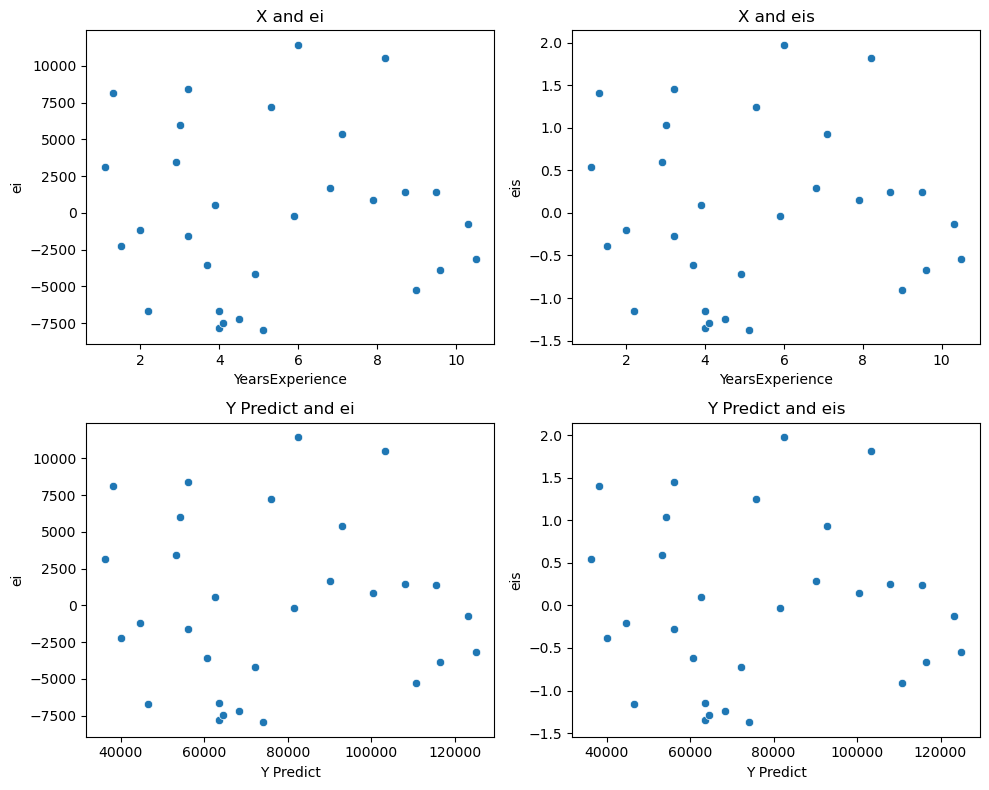

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

sns.scatterplot(
    data=data,
    x="YearsExperience",
    y="ei",
    ax=axes[0, 0]
)
axes[0, 0].set_title("X and ei")

sns.scatterplot(
    data=data,
    x="YearsExperience",
    y="eis",
    ax=axes[0, 1]
)
axes[0, 1].set_title("X and eis")

sns.scatterplot(
    data=data,
    x="Y Predict",
    y="ei",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Y Predict and ei")

sns.scatterplot(
    data=data,
    x="Y Predict",
    y="eis",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Y Predict and eis")

plt.tight_layout()
plt.show()

That random scatter show us our depent and indepent variables has no functional relationship.

Now, with ANOVA table we calculate F statistic and R^2  

# ANOVA Table, F Test, R^2, Adj. R^2

$$
\begin{array}{cccc}
\hline
\textbf{SS} & \textbf{df} & \textbf{MS} & \textbf{F} \\
\hline
SSR & k & \dfrac{SSR}{k} & \dfrac{MSR}{MSE} \\
SSE & n-k-1 & \dfrac{SSE}{n-k-1} &  \\
SST & n-1 &  &  \\
\hline
\end{array}
$$

$$
SST = SSR + SSE
$$


$$
SST = \sum_{i=1}^{n} (y_i - \bar{y})^2
$$

$$
SSR = \sum_{i=1}^{n} (\hat{y}_i - \bar{y})^2
$$

$$
SSE = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

$$
R^2 = \frac{SSR}{SST} = 1 - \frac{SSE}{SST}
$$


$$
\bar{R}^2 = 1 - \frac{SSE / (n - k - 1)}{SST / (n - 1)}
$$


In [27]:
data["yi^2"] = data["yi"] ** 2

SST = data["yi^2"].sum()
SSE = data["ei^2"].sum()
SSR = SST - SSE

In [29]:
R = SSR/SST
AdjR = 1 - (SSE/(30-2-1)/(SST/(30-1)))

print(f"R^2 Value: {R}\nAdjusted R^2 Value: {AdjR}")

R^2 Value: 0.9569566641435084
Adjusted R^2 Value: 0.9537682688948795


$$
H_0: \beta_1 = 0
$$

$$
H_1: \beta_1 \neq0
$$


In [30]:
F = (SSR/2)/(SSE/(30-2-1))
F_critical = 4.20 # for alpha=0.05

if F > F_critical:
    print("H0 is rejected: The regression model is statistically significant.")
else:
    print("H0 is not rejected: The regression model is not statistically significant.")

H0 is rejected: The regression model is statistically significant.


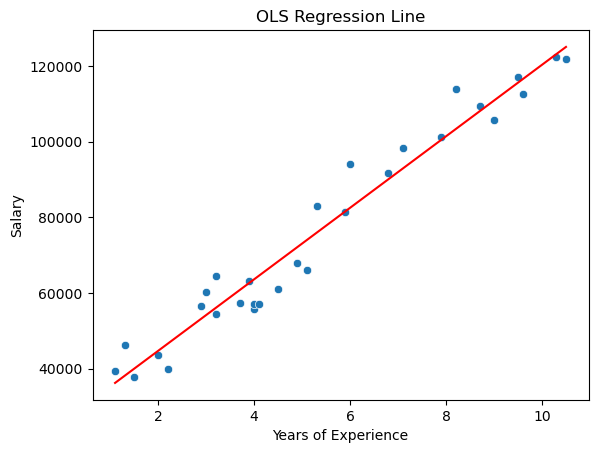

In [32]:
x = data["YearsExperience"]
y = data["Salary"]
y_hat = data["Y Predict"]

order = np.argsort(x)

sns.scatterplot(x=x, y=y)
plt.plot(x[order], y_hat[order], color="red")

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("OLS Regression Line")
plt.show()